<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day09_practice1_%EB%B0%94%EC%9A%B4%EB%94%A9%EB%B0%95%EC%8A%A4_IoU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 바운딩 박스와 IoU - 감지의 언어

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

torch.manual_seed(42)

In [10]:
# 셀 1. - 분류 vs 감지

# 분류(Classification)
# 출력: 클래스 확률 하나
# 예: [0.01, 0.02, ..., 0.85, ...] -> "이 이미지에는 무엇이 있는가?"

# 감지(Object Detection)
# 출력: 여러 객체에 대한 정보
# [ (박스, 클래스, 신뢰도),
#   (박스, 클래스, 신뢰도), ... ]
# -> "무엇이 어디에 있는가?"

# 분류: 이미지 전체를 보고 하나의 답을 찾음
# 감지: 이미지 안에서 여러 객체를 찾아 각각 박스 + 라벨을 붙임

In [4]:
# 셀 2. 박스 표기법 4가지
W, H = 640, 480   # 640x480 사이에서 같은 박스를 4가지로

xyxy = [160, 120, 480, 360]      # 좌상단(x1,y1) + 우하단 (x2,y2)
xywh = [160, 120, 320, 240]      # 좌상단 + 너비, 높이
cwcywh = [320, 240, 320, 240]    # 중심점 + 너비, 높이 (YOLO 학습 형식)
ratio = [0.25, 0.25, 0.75, 0.75] # xyxy 를 W,H로 나눈 '비율 좌표'

# 변환: 픽셀 xyxy -> 비율
def to_ratio(box, W, H):
  x1, y1, x2, y2 = box
  return [round(x1/W, 3), round(y1/H, 3), round(x2/W, 3), round(y2/H, 3)]

print("변환 확인:", to_ratio(xyxy, W, H), "== ratio ?", to_ratio(xyxy, W, H) == ratio)

변환 확인: [0.25, 0.25, 0.75, 0.75] == ratio ? True


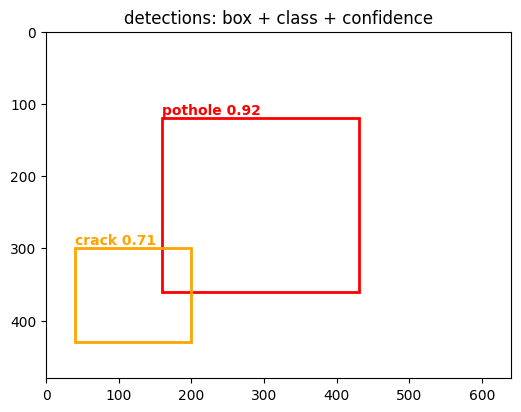

In [5]:
# 셀 3. 박스 그려보기 - 감지 결과의 생김새
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.set_xlim(0, W)
ax.set_ylim(H, 0) # 이미지 좌표: y는 아래로
ax.set_title("detections: box + class + confidence")

detections = [
    ([160, 120, 430, 360], "pothole 0.92", "red"),
    ([40, 300, 200, 430], "crack 0.71", "orange"),
]

for (x1, y1, x2, y2), label, color in detections:
  ax.add_patch(
      patches.Rectangle(
          (x1, y1), x2-x1, y2-y1,
          fill=False, color=color, lw=2
      )
  )
  ax.text(
      x1, y1-6, label,
      color=color, fontsize=10, weight="bold"
  )

plt.savefig("plot_boxes.png")
plt.show()

# 감지 결과의 표준 모습 (박스+클래스+신뢰도)

In [6]:
# 셀 4. IoU(Intersection over Union) - 교집합 넓이 / 합집합 넓이 -> 얼마나 겹치나
#   완벽히 겹침 = 1.0 / 전혀 안 겹침 = 0.0
#  예측 박스 채점 (정답과 IoU ≥ 0.5면 '맞았다'), NMS에서 중복 박스 판정

# 두 박스(xyxy)의 IoU
box_a = [100, 100, 300, 300] #
box_b = [200, 200, 400, 400]

# 교집합: 100 x 100 = 10,000
# 합집합: (200x200) + (200x200) - (100x100) = 70,000
print("\n IoU 손계산: 10000 / 70000 =", round(10000/70000, 4))

# 두 박스(xyxy)의 IoU
def iou(a, b):
  ix1, iy1 = max(a[0], b[0]), max(a[1], b[1]) # 200, 200
  ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])  # 300, 300
  iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1) # 100, 100
  inter = iw * ih
  area_a = (a[2]-a[0]) * (a[3]-a[1])  # 40,000
  area_b = (b[2]-b[0]) * (b[3]-b[1])  # 40,000
  return inter / (area_a + area_b - inter)

print("코드 계산:", round(iou(box_a, box_b), 4))

assert abs(iou(box_a, box_b) - 10000/70000) < 1e-9

#  겹침 정도별 IoU
cases = [([0,0,100,100], [0,0,100,100], "완전 일치"),
          ([0,0,100,100], [10,10,110,110], "살짝 어긋남"),
          ([0,0,100,100], [50,50,150,150], "반쯤 겹침"),
          ([0,0,100,100], [100,100,200,200], "모서리만 닿음")]

print("\nIoU : 겹침 정도")
for a, b, name in cases:
  print(f"{name:8s}: {iou(a,b):.3f}")


 IoU 손계산: 10000 / 70000 = 0.1429
코드 계산: 0.1429

IoU : 겹침 정도
완전 일치   : 1.000
살짝 어긋남  : 0.681
반쯤 겹침   : 0.143
모서리만 닿음 : 0.000


In [8]:
# 셀 5. NMS - 한 물체에 붙은 중복 박스 정리

candidates = [
    ([150, 110, 470, 350], 0.90),
    ([160, 120, 480, 360], 0.85),
    ([155, 125, 465, 355], 0.80),
    ([40, 300, 200, 430], 0.71),
]

def nms(dets, iou_thr=0.5):
  dets = sorted(dets, key=lambda d: d[1], reverse=True) # 신뢰도 기준으로 내림차순 정렬
  keep=[]
  while dets:
    best = dets.pop(0)
    keep.append(best)
    # dets = [d for d in dets if iou(best[0], d[0]) < iou_thr]
    filtered = []
    for d in dets:
      print(f"Best: {best[0]} | Target: {d[0]} | IoU: {iou(best[0], d[0]):.4f}")
      if iou(best[0], d[0]) < iou_thr: filtered.append(d)
    dets = filtered
  return keep

result = nms(candidates)
print(f"NMS: 후보 {len(candidates)}개 → {len(result)}개")
for box, conf in result:
  print(f"유지: conf {conf} @ {box}")

Best: [150, 110, 470, 350] | Target: [160, 120, 480, 360] | IoU: 0.8663
Best: [150, 110, 470, 350] | Target: [155, 125, 465, 355] | IoU: 0.8902
Best: [150, 110, 470, 350] | Target: [40, 300, 200, 430] | IoU: 0.0263
NMS: 후보 4개 → 2개
유지: conf 0.9 @ [150, 110, 470, 350]
유지: conf 0.71 @ [40, 300, 200, 430]
